# 使用 PROC MODECLUS 对电网监测站点进行基于密度的聚类

## 摘要

某电力配电企业使用 PROC MODECLUS，仅凭地图坐标，对其电网监测站点（变电站与馈线传感器）进行非参数的、基于密度的聚类。MODECLUS 会在站点之间估计一个密度曲面，并将密度较高、由低密度间隙分隔开的区域视为聚类。在均匀核半径为 3 公里的设置下，对 90 个模拟站点运行该过程，成功还原出我们内置于数据中的三个密集服务聚集区，它们是三个最大的聚类（分别为 24、24 和 21 个站点），而分散的农村站点则落入稀疏区域，各自拆分成一到两个站点的微型聚类。这组孤立站点正是本分析的业务交付物：为资本规划团队提供的偏远资产候选清单。

## 数据来源

| 数据集 | 行数 | 说明 |
|---------|------|------|
| `grid_sites` | 90 | 使用 `call streaminit(70531)` 与 `rand()` 内联生成的模拟电力配电监测站点数据。三个密集服务聚集区（城区核心、郊区、工业区）取自围绕不同地图中心的二元正态分布，另有 22 个分散的农村站点在整个辖区内均匀分布。 |

| 变量 | 类型 | 说明 |
|----------|------|------|
| `site_id` | 数值 | 唯一的监测站点标识（1-90）。 |
| `region` | 字符 | 记录每个站点生成方式的规划标签（城区核心、郊区、工业区、农村）；聚类时不使用该变量。 |
| `x_km`、`y_km` | 数值 | 站点在企业规划网格上的公里坐标；用于聚类的变量。 |
| `peak_load_mw` | 数值 | 该站点观测到的年度峰值负荷（兆瓦）；用于后续解读。 |

# 电网监测站点的基于密度聚类

某区域电力配电企业运营着一张遍布其服务辖区的**监测站点**网络——变电站与馈线传感器。规划人员希望仅凭地理位置，在不预先指定分组数量的前提下，将这些站点自然地划分为**服务聚集区**，并识别出不属于任何密集聚集区的**孤立农村资产**。

`PROC MODECLUS` 非常适合这项任务：它执行*非参数的、基于密度*的聚类。该过程先在各站点之间估计一个密度函数，再将由低密度间隙分隔、站点密度较高的区域视为聚类。稀疏的离群点会各自落入自己的小型聚类，而不会被并入某个聚集区——这正是我们希望用来标记偏远站点的行为。

本笔记本将：
1. 生成一个包含 90 个站点的真实模拟站点网络。
2. 使用**均匀核**估计站点密度，并扫描平滑半径 `R=`，以确认识别出的聚集区是否稳定。
3. 固定一个工作半径，写出包含每个站点密度与聚类标签的 `OUT=` 数据集，并绘制结果地图。

## 第 1 步——生成模拟监测站点网络

我们模拟了 90 个站点。三个密集的**服务聚集区**取自围绕不同地图中心的二元正态分布（城区核心约在 (12, 30)，郊区约在 (30, 15)，工业区约在 (20, 42)），分别形成 24、24 和 20 个站点的紧凑高密度团块。另有一组 22 个**农村**站点在整个辖区内均匀分布，形成一批企业会视为孤立的稀疏散点。

`region` 标签记录了每个站点的生成方式；我们特意在聚类中**不使用**该变量，让 MODECLUS 仅凭坐标重新发现数据结构。`peak_load_mw` 则保留下来，供后续解读使用。

In [1]:
数据 grid_sites;
   调用 streaminit(70531);
   长度 region $ 24;

   /* Dense urban service pocket */
   循环 site_id = 1 到 24;
      region = '城区核心';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      输出;
   结束;

   /* Suburban pocket */
   循环 site_id = 25 到 48;
      region = '郊区';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      输出;
   结束;

   /* Industrial pocket (higher peak load) */
   循环 site_id = 49 到 68;
      region = '工业区';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      输出;
   结束;

   /* Scattered rural sites (sparse, low load) */
   循环 site_id = 69 到 90;
      region = '农村';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      输出;
   结束;
运行;

标题 '模拟电网监测站点';
过程 means 数据=grid_sites n mean std MIN MAX maxdec=2;
   分类 region;
   变量 x_km y_km peak_load_mw;
   标签 region='区域' x_km='东坐标(公里)' y_km='北坐标(公里)' peak_load_mw='峰值负荷(兆瓦)';
运行;


                                                        模拟电网监测站点                                                        

                                                  The MEANS Procedure

                                       Analysis Variable : x_km 东坐标(公里)

        区域                    N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        农村                       22          29.79          10.62          11.06          47.45
        城区核心                     24          12.07           1.34           8.65          14.42
        工业区                      20          20.36           0.96          18.52          21.53
        郊区                       24          29.96           1.73          26.51          33.60
        ---------------------------------------------------------------------------------------

                                       Analysis Variable : y_


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 模拟电网监测站点.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


均值结果证实了三个紧凑聚集区与一个分散群体的存在。三个密集区域的坐标标准差都很小（每个坐标轴大约 1-1.7 公里），且中心彼此分离明显；而农村组则分散在整张网格上（两个坐标轴的标准差均超过 10 公里）。峰值负荷同样能区分各聚集区——工业区站点平均约 6 兆瓦，城区核心约 4.6 兆瓦，郊区约 2.7 兆瓦，农村站点约 1.5 兆瓦——在得到地理聚类结果后，这一信息很有参考价值。

## 第 2 步——均匀核密度聚类与半径扫描

均匀核密度估计使用**半径 `R=`**：位于 `R` 公里范围内的每个站点都会计入该站点的局部密度。`R` 过小会得到起伏不定的密度，使辖区支离破碎；`R` 过大则会过度平滑，把各聚集区合并到一起。经验丰富的 SAS 使用者从不只依赖单一取值——他们会扫描一系列半径，寻找**稳定**的聚类数量：密集聚集区应保持不变，只有零散单点的数量会漂移。

这里 `M=1` 选择聚类方法 1（标准非参数方法），并在一次调用中请求半径 `R=2.5 到 4 按照 0.5`。MODECLUS 会针对每个半径各运行一次分析，并报告对应的聚类数量。`SHORT` 用于抑制冗长的逐聚类统计信息。

In [2]:
标题 '均匀核密度聚类的电网监测站点';
title2 '半径扫描 R = 2.5 至 4.0 公里';

过程 modeclus 数据=grid_sites m=1 r=2.5 到 4 按照 0.5 short;
   变量 x_km y_km;
   id site_id;
   标签 x_km='东坐标(公里)' y_km='北坐标(公里)' site_id='站点编号';
运行;


                                                     均匀核密度聚类的电网监测站点                                                     
                                                 半径扫描 R = 2.5 至 4.0 公里                                                  


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: 东坐标(公里) 北坐标(公里)

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to 均匀核密度聚类的电网监测站点.
NOTE: Option TITLE2 changed to 半径扫描 R = 2.5 至 4.0 公里.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


聚类数量在整个扫描过程中只发生了平缓的变化——`R=2.5` 时为 23 个聚类，`R=3.0` 时为 22 个，`R=3.5` 时为 19 个，`R=4.0` 时为 18 个。较高的原始计数来自分散的农村站点：每个孤立站点都处于自己稀疏的邻域中，各自形成一个单点聚类，因此这 18-23 个「聚类」中的大多数都是单点聚类。真正重要、始终保持不变的是底层结构——三个密集聚集区在每个半径下都始终是三个庞大且彼此分离明显的聚类。随着 `R` 增大，少数分散的单点会与邻近站点或附近聚集区合并，这就是总数缓慢下降而不是剧烈波动的原因。这种稳定性正是三聚集区结果真实存在、而非某个带宽下的偶然产物的信号。

## 第 3 步——用于绘图的最终聚类结果

既然已经看到三个聚集区在整个扫描过程中都很稳定，我们便固定单一工作半径（`R=3` 公里），并请求 **ALL** 选项以显示完整的逐聚类信息，同时用 **OUT=** 写出原始坐标，连同 `DENSITY` 密度估计与 `CLUSTER` 聚类归属，以便绘制结果地图。聚类按众数密度从高到低编号，因此密度最高的聚集区是聚类 1、2、3，稀疏站点则排在较大的编号之后。

In [3]:
标题 '最终基于密度的聚类结果';
title2 '均匀核，R = 3 公里';

过程 modeclus 数据=grid_sites m=1 r=3 out=join_out ALL;
   变量 x_km y_km;
   id site_id;
   标签 x_km='东坐标(公里)' y_km='北坐标(公里)' site_id='站点编号';
运行;


                                                      最终基于密度的聚类结果                                                       
                                                      均匀核，R = 3 公里                                                      


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: 东坐标(公里) 北坐标(公里)

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393



NOTE: Option TITLE changed to 最终基于密度的聚类结果.
NOTE: Option TITLE2 changed to 均匀核，R = 3 公里.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


聚类汇总清楚地展现了这一结构。`R=3` 的结果给出了 **22 个聚类**，但按密度可明显分为几个层级：

- **聚类 1**——24 个站点，众数密度约 0.0090（城区核心聚集区）。
- **聚类 2**——24 个站点，众数密度约 0.0079（郊区聚集区）。
- **聚类 3**——21 个站点，众数密度约 0.0079（工业区聚集区；其中吸纳了一个恰好落在边缘的农村站点）。
- **聚类 4-22**——一个三站点群体与十八个单站点聚类，众数密度均约 0.0004，比聚集区稀疏约二十倍。

三个密集聚集区共涵盖 90 个站点中的 69 个；其余 21 个站点为分散的农村资产，各自独处或近乎独处于低密度邻域中。区分服务聚集区与孤立站点的是密度本身，而非预设的聚类数量。

## 第 4 步——绘制聚类地图

我们根据每个站点是否落入三个密集聚集区之一（`cluster <= 3`）或落入某个稀疏微聚类，为其打上标签，然后按该状态着色，将所有站点绘制在地图坐标上。这就是规划人员所需的视角：密集聚集区作为服务辖区加以管理，孤立站点则被标记出来做单独处理。

                                                     还原的服务聚集区与孤立站点                                                      
                                                    均匀核密度聚类，R = 3 公里                                                    




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to 还原的服务聚集区与孤立站点.
NOTE: Option TITLE2 changed to 均匀核密度聚类，R = 3 公里.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


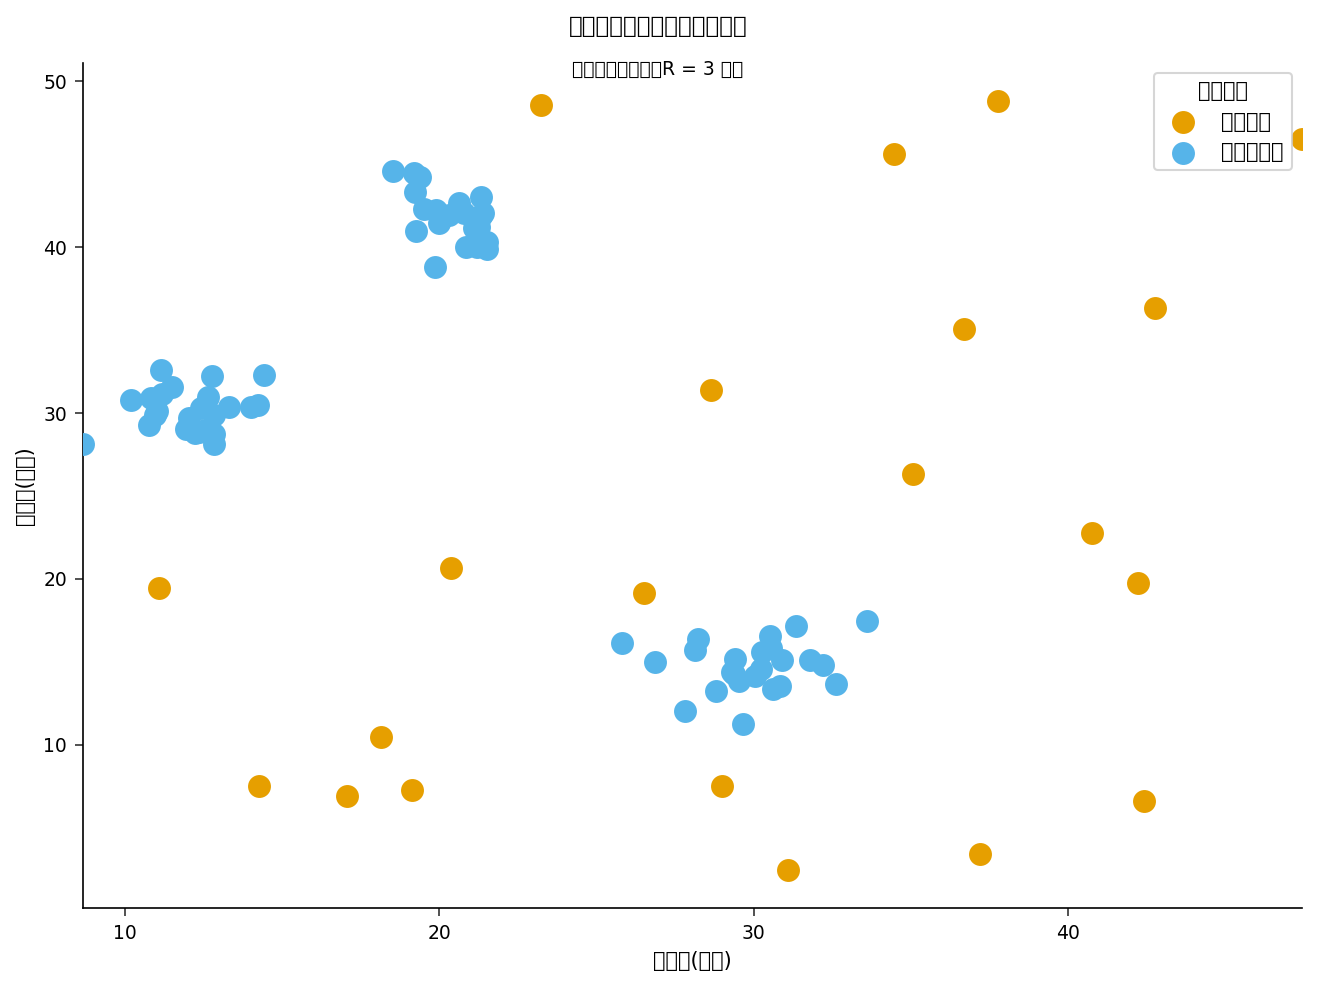

In [4]:
数据 mapped;
   设置 join_out;
   长度 status $ 32;
   如果 cluster <= 3 那么 status = '密集聚集区';
   否则 status = '孤立站点';
运行;

标题 '还原的服务聚集区与孤立站点';
title2 '均匀核密度聚类，R = 3 公里';
过程 SGPLOT 数据=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=cluster
                           MARKERATTRS=(size=10);
   XAXIS 标签='东坐标(公里)';
   YAXIS 标签='北坐标(公里)';
   keylegend / 标题='站点状态';
运行;

标题;


## 结果解读

**MODECLUS 发现了什么。** 仅凭 `(x_km, y_km)`，该过程便还原出我们内置于数据中的三个密集服务聚集区——城区核心、郊区与工业区团块——它们是三个最大、密度最高的聚类（分别为 24、24 和 21 个站点）。在整个辖区内均匀分布的分散农村站点则落入稀疏区域，各自拆分成一到两个站点的聚类，而不会被并入某个聚集区。在地图上，它们是与三个紧凑团块分离开来的点。这组孤立站点正是本分析的业务交付物：为资本规划团队提供的偏远资产候选清单。

**为什么平滑扫描很重要。** 对于非参数密度聚类而言，没有哪一个 `R` 值是绝对权威的。扫描 `R=2.5 到 4 按照 0.5` 让我们能够确认，各聚集区在不同平滑水平下是**稳定**的，而不是某一带宽下的偶然产物。在整个扫描过程中，聚类数量只是从 23 缓慢降到 18，且变化完全来自零散单点的数量——三个密集聚集区始终保持不变。当结构像这样保持稳定时，我们就得到了一个站得住脚的结果；如果数量剧烈波动，那么这一结构就会很脆弱，不应据此推动投资决策。

**密度为结果分出层级。** 由于聚类是按众数密度从高到低编号的，聚集区与孤立站点之间的划分是量化的，而非任意的：三个聚集区的众数密度都在 0.008-0.009 附近，而每个孤立站点的众数密度都在 0.0004 附近，比聚集区稀疏约二十倍。规划人员可以设定一个密度下限，直接从 `join_out` 的 `CLUSTER` 与 `DENSITY` 列中读出孤立资产。

**实际用途。** `join_out` 数据集为每个站点提供了密度与聚类标签，可以作为下游工作的起点——按服务聚集区安排班组与备件、规划巡检路线，或在密度最高的工业聚类（`peak_load_mw` 最高，约 6 兆瓦）中优先安排电网加固，同时为孤立的农村站点安排单独的低频率维护。

*关于模拟数据的说明：* 坐标与负荷数据使用固定种子（`call streaminit(70531)`）模拟生成，因此本笔记本可以完全离线复现；在真实的公用事业数据中，你需要替换为实测的站点坐标与计量的峰值负荷。具体的聚类数量取决于随机抽样结果与所选半径。